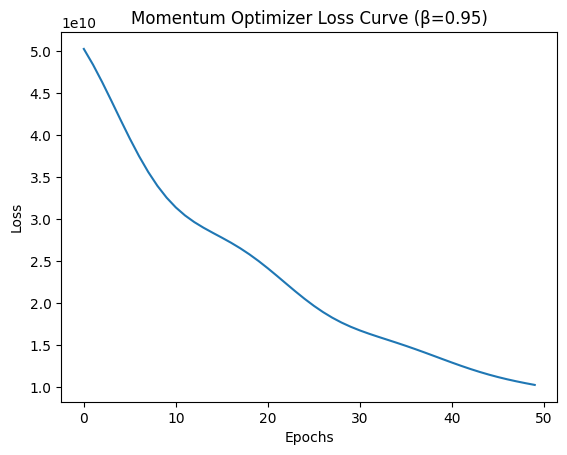

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.optimizers import OptimizerEngine

# Load dataset (correct path!)
df = pd.read_csv("data/final_prepared.csv")
X = df.drop(columns=["median_house_value"]).values
y = df["median_house_value"].values

# Initialize optimizer with Momentum
w = np.zeros(X.shape[1])
b = 0
optimizer = OptimizerEngine(optimizer_type="momentum", learning_rate=0.01, epochs=50)

losses = []
for epoch in range(optimizer.epochs):
    y_pred = X.dot(w) + b
    grad_w = (2/X.shape[0]) * X.T.dot(y_pred - y)
    grad_b = (2/X.shape[0]) * np.sum(y_pred - y)

    w = optimizer.update_params(w, grad_w, epoch)
    b = b - optimizer.lr * grad_b

    loss = np.mean((y - y_pred)**2)
    losses.append(loss)

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Momentum Optimizer Loss Curve (β=0.95)")
plt.show()

In [2]:
import os
os.makedirs("../results", exist_ok=True)
np.save("../results/momentum_loss_beta_09.npy", losses)
# After rerun with β=0.95
np.save("../results/momentum_loss_beta_095.npy", losses)

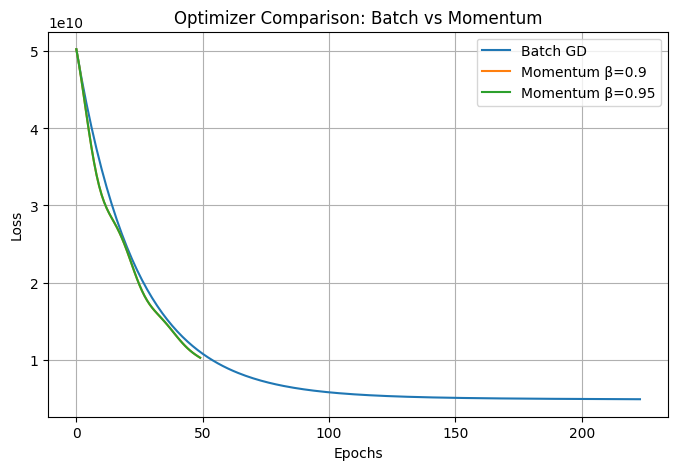

In [3]:
import numpy as np
import matplotlib.pyplot as plt

batch_loss = np.load("../results/batch_loss.npy")
momentum_09 = np.load("../results/momentum_loss_beta_09.npy")
momentum_095 = np.load("../results/momentum_loss_beta_095.npy")

plt.figure(figsize=(8,5))
plt.plot(batch_loss, label="Batch GD")
plt.plot(momentum_09, label="Momentum β=0.9")
plt.plot(momentum_095, label="Momentum β=0.95")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Optimizer Comparison: Batch vs Momentum")
plt.legend()
plt.grid(True)
plt.show()